## Guided Back-Propogation with PyTorch Hooks

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import models, transforms

import urllib.request

In [4]:
def process_image(img_path):
    img=Image.open(img_path).convert('RGB')

    # Transforms used by imagenet models
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    return transform(img).unsqueeze(0)

In [5]:
def display_output(output, n=5):
    # Download the categories
    url='https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
    urllib.request.urlretrieve(url, 'imagenet_classes.txt')

    with open('imagenet_classes.txt', 'r') as f:
        categories=[s.strip() for s in f.readlines()]

    # Show top categories per image
    probabilities=F.softmax(output[0], dim=0)
    top_prob, top_catid=torch.topk(probabilities, n)

    for i in range(top_prob.size(0)):
        print(categories[top_catid[i]], top_prob[i].item())

    return top_catid[0]

(-0.5, 2530.5, 2530.5, -0.5)

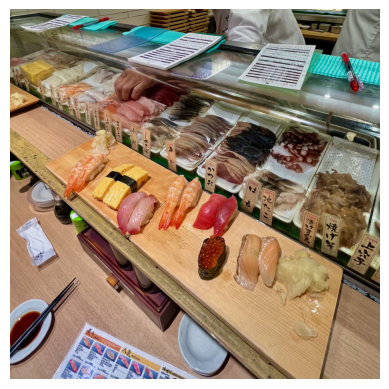

In [6]:
# Load a sample image
img_path='sushi.png'
img=Image.open(img_path).convert('RGB')

plt.imshow(img)
plt.axis('off')

In [7]:
# Using a VGG16 model
model=models.vgg16(pretrained=True)

device=torch.device('mps' if torch.backends.mps.is_built()
                    else 'cuda' if torch.cuda.is_available()
                    else 'cpu')

model.to(device)

model.eval()

C:\Users\Kushal\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Kushal\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
org_img_tensor=process_image(img_path=img_path)
org_img_tensor=org_img_tensor.to(device)

# Clone tensor to avoid in-place operations
img_tensor=org_img_tensor.clone()
img_tensor.requires_grad_() # Enable gradient tracking

predictions=model(img_tensor)

# Decode the output
display_output(predictions, n=5)

grocery store 0.2973235249519348
confectionery 0.16054582595825195
tobacco shop 0.15370549261569977
bakery 0.13208985328674316
hotdog 0.07943767309188843


tensor(582)

In [9]:
# Reset gradients
model.zero_grad()

# Select class with highest score
target_class=predictions.argmax()

# Compute gradients w.r.t logit by performing backward pass
predictions[:, target_class].backward()

In [10]:
# Get the gradients
std_backprop_grads=img_tensor.grad.detach().cpu().numpy()
print(std_backprop_grads.shape)

(1, 3, 224, 224)


In [11]:
def process_gradients(grads_in, activation='None', skew=True, normalize=True, grayscale=False):
    # Copy the gradients
    grads=np.copy(grads_in)

    # Transpose the gradients
    if len(grads.shape)>=3:
        grads=np.transpose(grads, (1, 2, 0))

    # Get the absolute value of the gradients
    if activation=='relu':
        grads=np.maximum(0, grads)
    elif activation=='abs':
        grads=np.abs(grads)
    else:
        grads=grads

    # Normalize the gradients
    if normalize:
        grads-=np.min(grads)
        grads/=(np.max(grads)+1e-9)

    if grayscale:
        grads=np.mean(grads, axis=-1)

    return grads

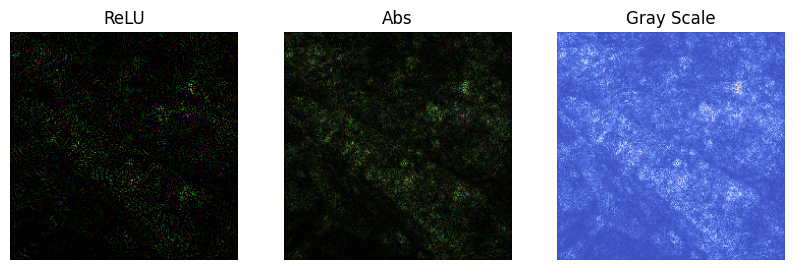

In [12]:
grads=std_backprop_grads[0]

# Process the gradients
relu_grads=process_gradients(
    grads_in=grads,
    activation='relu'
)

abs_grads=process_gradients(
    grads_in=grads,
    activation='abs'
)

gray_grads=process_gradients(
    grads_in=grads,
    activation='abs',
    grayscale=True,
    skew=False
)

fig, ax=plt.subplots(1, 3, figsize=(10, 5))

im0=ax[0].imshow(relu_grads)
ax[0].title.set_text('ReLU')

im1=ax[1].imshow(abs_grads)
ax[1].title.set_text('Abs')

im2=ax[2].imshow(gray_grads, cmap='coolwarm')
ax[2].title.set_text('Gray Scale')

for a in ax:
    a.axis('off')

### PyTorch Hooks

- These are the powerful functions that allow us to save information at any point in the network, at any layer in a network.

- These allow us to change how gradients flow through the network.

In [13]:
def replace_relu(model):
    for name, child in model.named_children():
        if isinstance(child, torch.nn.ReLU):
            setattr(model, name, torch.nn.ReLU(inplace=False))
            print(f'Replacing ReLU activation in layer: {name}')
        else:
            replace_relu(child)

replace_relu(model=model)

Replacing ReLU activation in layer: 1
Replacing ReLU activation in layer: 3
Replacing ReLU activation in layer: 6
Replacing ReLU activation in layer: 8
Replacing ReLU activation in layer: 11
Replacing ReLU activation in layer: 13
Replacing ReLU activation in layer: 15
Replacing ReLU activation in layer: 18
Replacing ReLU activation in layer: 20
Replacing ReLU activation in layer: 22
Replacing ReLU activation in layer: 25
Replacing ReLU activation in layer: 27
Replacing ReLU activation in layer: 29
Replacing ReLU activation in layer: 1
Replacing ReLU activation in layer: 4


In [14]:
# Dictionary to store gradients
gradients={}

def relu_hooks(module, grad_in, grad_out, layer_name):
    # module(nn.Module): module where the hook is applied
    # grad_in: Gradients w.r.t the input of the module
    # grad_out: Gradients w.r.t the output of the module
    # layer_name: Name of the module

    modified_grad=[]

    for g in grad_in:
        if g is not None:
            modified_grad.append(torch.clamp(g, min=0.0))
        else:
            modified_grad.append(None)

    gradients[layer_name]=modified_grad[0].detach().cpu().numpy().squeeze()

    return tuple(modified_grad)

In [15]:
# Register the hook for all layers
for name, layer in model.named_modules():
    if isinstance(layer, torch.nn.ReLU):
        layer.register_backward_hook(
            lambda m, gi, go, n=name: relu_hooks(m, gi, go, n)
        )
        print(f'ReLU hook registered for {name}')

ReLU hook registered for features.1
ReLU hook registered for features.3
ReLU hook registered for features.6
ReLU hook registered for features.8
ReLU hook registered for features.11
ReLU hook registered for features.13
ReLU hook registered for features.15
ReLU hook registered for features.18
ReLU hook registered for features.20
ReLU hook registered for features.22
ReLU hook registered for features.25
ReLU hook registered for features.27
ReLU hook registered for features.29
ReLU hook registered for classifier.1
ReLU hook registered for classifier.4


### Guided Back-Prop for Target Logit

In [16]:
img_tensor=org_img_tensor.clone()
img_tensor.requires_grad_()
model.zero_grad()

predictions=model(img_tensor)

target_class=predictions.argmax()

predictions[:, target_class].backward()

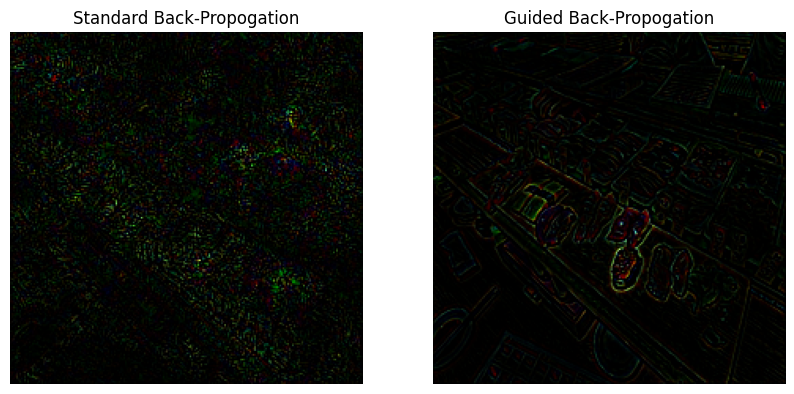

In [17]:
grads=img_tensor.grad.detach().cpu().numpy().squeeze()

grads=process_gradients(
    grads_in=grads,
    activation='relu'
)

fig, ax=plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(relu_grads)
ax[0].title.set_text('Standard Back-Propogation')

ax[1].imshow(grads)
ax[1].title.set_text('Guided Back-Propogation')

for a in ax:
    a.axis('off')

### Guided Back-Propogation for Intermediate Layers

(64, 224, 224)


(-0.5, 223.5, 223.5, -0.5)

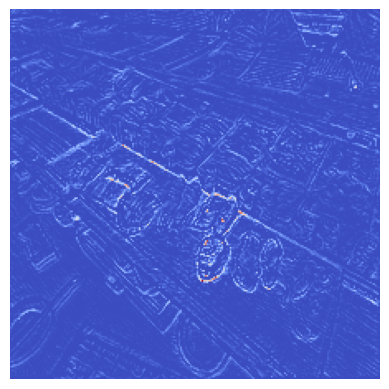

In [18]:
layer='features.1'

layer_grads=gradients[layer]
print(layer_grads.shape)

# Select a random feature map
i=np.random.randint(0, layer_grads.shape[0])
feature_map_grads=layer_grads[i]

# Processing the gradients
feature_map_grads=process_gradients(feature_map_grads)

# Display the gradients
plt.imshow(feature_map_grads, cmap='coolwarm')
plt.axis('off')

### Guided Back-Propogation for Elements in a Layer

In [19]:
activations={}

def act_hook_fn(module, input, output, layer_name):
    activations[layer_name]=output.clone()
    print(f'Activation stored for {layer_name}')

In [21]:
for name, layer in model.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        layer.register_forward_hook(
            lambda m, i, o, n=name: act_hook_fn(m, i, o, n)
        )
        print(f'Forward hook registered for {name}')

Forward hook registered for features.0
Forward hook registered for features.2
Forward hook registered for features.5
Forward hook registered for features.7
Forward hook registered for features.10
Forward hook registered for features.12
Forward hook registered for features.14
Forward hook registered for features.17
Forward hook registered for features.19
Forward hook registered for features.21
Forward hook registered for features.24
Forward hook registered for features.26
Forward hook registered for features.28


In [22]:
img_tensor=org_img_tensor.clone()
img_tensor.requires_grad_()
model.zero_grad()

predictions=model(img_tensor)

# Get the activations of the conv layers
layer_act=activations['features.21'][0]
print(layer_act.shape)

Activation stored for features.0
Activation stored for features.0
Activation stored for features.2
Activation stored for features.2
Activation stored for features.5
Activation stored for features.5
Activation stored for features.7
Activation stored for features.7
Activation stored for features.10
Activation stored for features.10
Activation stored for features.12
Activation stored for features.12
Activation stored for features.14
Activation stored for features.14
Activation stored for features.17
Activation stored for features.17
Activation stored for features.19
Activation stored for features.19
Activation stored for features.21
Activation stored for features.21
Activation stored for features.24
Activation stored for features.24
Activation stored for features.26
Activation stored for features.26
Activation stored for features.28
Activation stored for features.28
torch.Size([512, 28, 28])


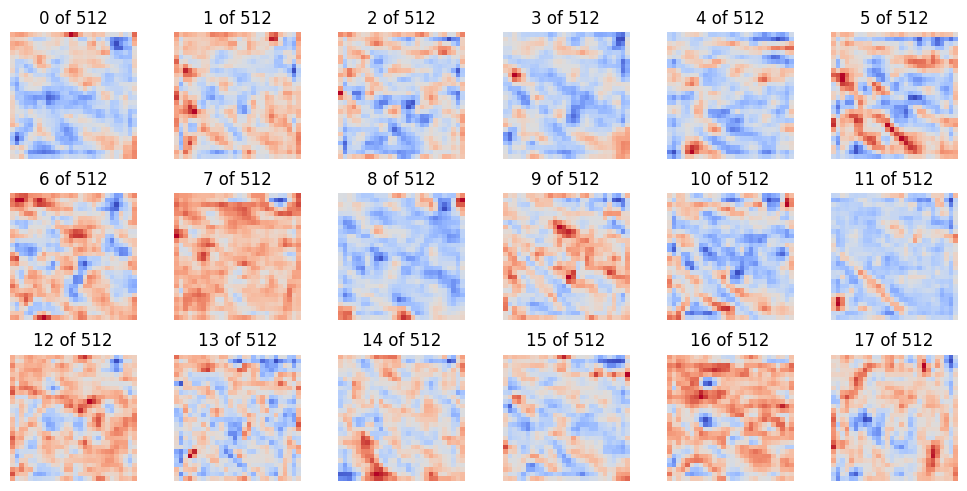

In [23]:
fig, ax=plt.subplots(3, 6, figsize=(10, 5))

for i, act in enumerate(layer_act[0:18]):
    act_copy=act.clone().detach().cpu().numpy()
    act_copy=process_gradients(act_copy, skew=False)

    ax[i//6, i%6].imshow(act_copy, cmap='coolwarm')
    ax[i//6, i%6].set_title(f'{i} of {layer_act.shape[0]}')
    ax[i//6, i%6].axis('off')

plt.tight_layout()

In [24]:
layer_act[0][14, 14].backward()

(-0.5, 223.5, 223.5, -0.5)

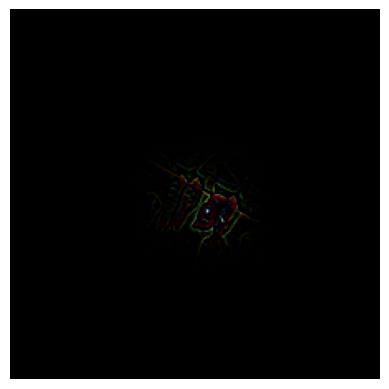

In [25]:
grads=img_tensor.grad.detach().cpu().numpy().squeeze()

grads=process_gradients(
    grads_in=grads,
    activation='relu'
)

plt.imshow(grads)
plt.axis('off')